# SVR vs. KRR: Sine Data Set
Import libraries and generate data set.

        Phy      NO2       NO3        NH4        PO4 Site       Bay  Depth
Chl_a                                                                     
6.66   0.74  0.21830  0.522735  31.784807  15.317651  XVI  West Bay  1.097
6.45   0.78  0.21830  0.522735  31.784807  15.317651  XVI  West Bay  1.098
6.27   0.77  0.21830  0.522735  31.784807  15.317651  XVI  West Bay  1.098
6.13   0.58  0.21495  0.527931  30.446107  14.834307  XVI  West Bay  2.004
6.10   0.57  0.21495  0.527931  30.446107  14.834307  XVI  West Bay  2.004


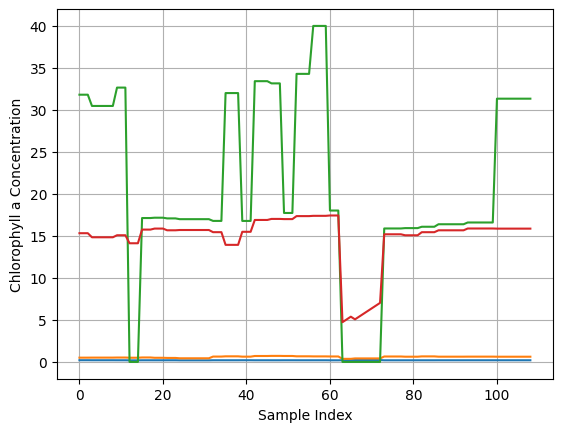

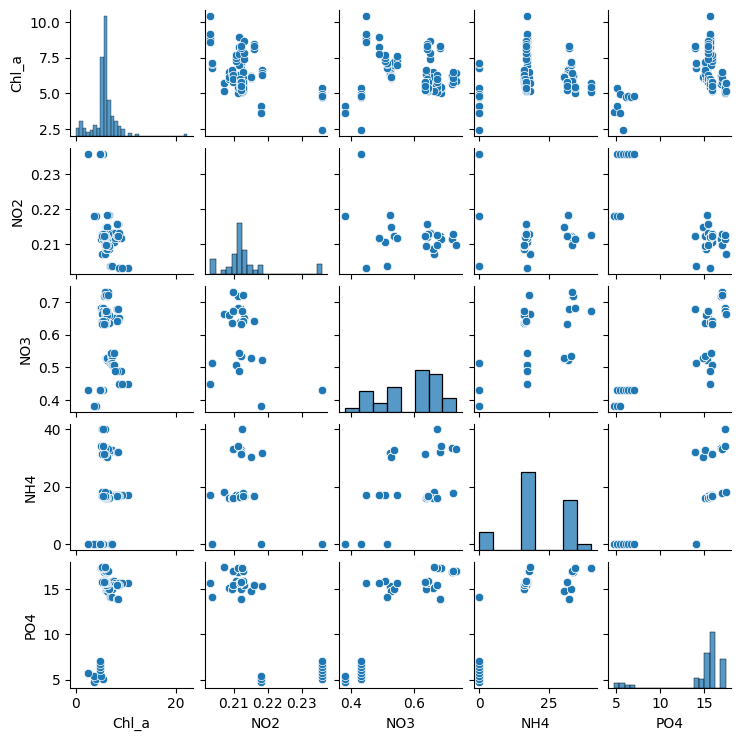

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ExpSineSquared
from sklearn.gaussian_process.kernels import WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge

url = 'https://raw.githubusercontent.com/kspilario/predict_chlorophyll/refs/heads/main/chlor.csv'
df = pd.read_csv(url, index_col=0)
print(df.head(5))
X = df[['NO2', 'NO3', 'NH4', 'PO4']].dropna() # we can change the imputation strategy here
y = X.index.values

plt.plot(np.arange(0,len(X)),X)
plt.grid()
plt.ylabel('Chlorophyll a Concentration')
plt.xlabel('Sample Index')
plt.show()

df_reset = df.reset_index()
# sns.pairplot(df_reset[['NO2', 'NO3', 'NH4', 'PO4', 'Chl_a']], hue='Chl_a', height=1.5)
sns.pairplot(df_reset[['Chl_a', 'NO2', 'NO3', 'NH4', 'PO4']], height=1.5)
plt.show()

### We can investigate different scenarios of the train/test split of the 200 samples:

Option 1: First 100 as training, next 100 as testing

In [5]:
# X_train, X_test, y_train, y_test = x[:100], x[100:], y[:100], y[100:]

Option 2: Random 100 as training, random 100 as testing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(76, 4) (33, 4) (76,) (33,)


Option 3: First 50 and last 50 as training, middle 100 as testing

In [7]:
# X_train, X_test, y_train, y_test = np.concatenate([x[:50], x[150:]]),x[50:150],\
#                                    np.concatenate([y[:50], y[150:]]),y[50:150]

Pick one option above, then proceed to visualize the data.

(76, 1) (33, 1) (76,) (33,)


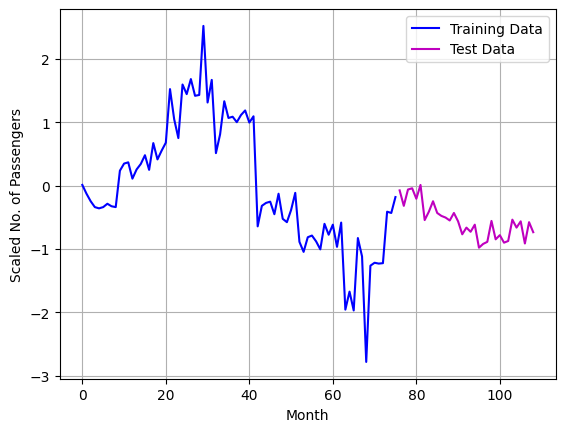

(76, 1)
(76, 1)
(33, 1)
(33, 1)


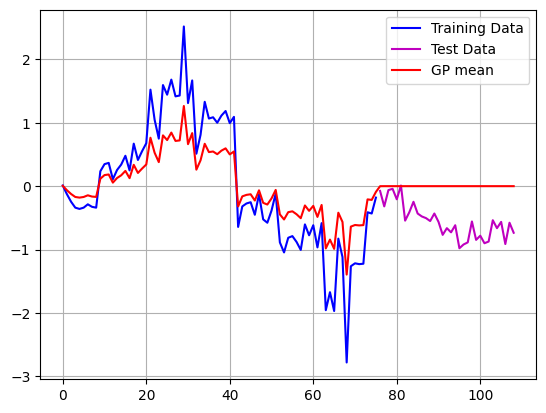

rbf
Training MSE: 0.24713496415803907
Testing MSE: 0.38380890335576257


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

train_size = int(len(X) * 0.7)
X_train = np.arange(0,train_size).reshape(-1,1)
X_test = np.arange(train_size,len(X)).reshape(-1,1)
y_train, y_test = y[0:train_size], y[train_size:]

scaler = StandardScaler()
# scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

plt.plot(np.arange(0, len(y_train_scaled)), y_train_scaled.ravel(), 'b')
plt.plot(np.arange(len(y_train_scaled), len(y_train_scaled) + len(y_test_scaled)), y_test_scaled.ravel(), 'm')
plt.grid()
plt.legend(('Training Data', 'Test Data'))
plt.ylabel('Scaled No. of Passengers')
plt.xlabel('Month')
plt.show()
print(X_train.shape)
print(y_train_scaled.shape)
print(X_test.shape)
print(y_test_scaled.shape)

X = np.arange(0, len(X)).reshape(-1, 1)
y_mean = y_train_scaled.mean()
# krr = make_pipeline(KernelRidge(kernel='rbf',gamma=5)).fit(X_train, y_train_scaled - y_mean)
krr = make_pipeline(KernelRidge(kernel='rbf', alpha=1.0)).fit(X_train, y_train_scaled - y_mean)
y_krr = krr.predict(X)
y_krr += y_mean
plt.plot(np.arange(0,len(y_train_scaled)), y_train_scaled,'b',label='Training Data')
plt.plot(np.arange(len(y_train_scaled), len(y_train_scaled) + len(y_test_scaled)), y_test_scaled, 'm', label='Test Data')
plt.plot(X, y_krr, 'r', label='GP mean')
# plt.ylabel('Scaled No. of Passengers')
# plt.xlabel('Month')
plt.grid()
plt.legend()
plt.show()
print(krr.named_steps['kernelridge'].kernel)
train_mse = mean_squared_error(y_train_scaled, y_krr[:train_size])
test_mse = mean_squared_error(y_test_scaled, y_krr[train_size:len(df)])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")